MIT License

Copyright (c) 2025 Yaoxi Tan

Permission is hereby granted, free of charge, to any person obtaining a copy of this software and associated documentation files (the "Software"), to deal
in the Software without restriction, including without limitation the rights
to use, copy, modify, merge, publish, distribute, sublicense, and/or sell
copies of the Software, and to permit persons to whom the Software is
furnished to do so, subject to the following conditions:

The above copyright notice and this permission notice shall be included in all
copies or substantial portions of the Software.

THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR
IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY,
FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL THE
AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER
LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING FROM,
OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER DEALINGS IN THE
SOFTWARE.

**Black-Scholes PDE**

It is widely used in financial industry to price option, which is a financial derivative with nonlinear payoff.

$$
\frac{\partial V}{\partial t} = \frac{1}{2}\sigma^2 S^2 \frac{\partial^2 V}{\partial S^2} + rS \frac{\partial V}{\partial S} - rV
$$
where $V(S,t)$ is option price, $S$ is underlying asset price, $t$ is the time to maturity, $\sigma$ is volatility, and $r$ is risk-free interest rate.

For a European call option, the initial condition is defined by the payoff at maturity:
$$
V(S, 0) = \max(S - K, 0)
$$
where $K$ is strike price. The boundary conditions are:
$$
V(0, t) = 0
$$
    
$$
\lim_{S \to +\infty} V(S, t) = S
$$

For a European put option, the initial condition is defined by the payoff at maturity:
$$
V(S, 0) = \max(K - S, 0)
$$
The boundary conditions are:
$$
V(0, t) = Ke^{-rt}
$$
    
$$
\lim_{S \to +\infty} V(S, t) = 0
$$


**Space Discretization**

(1) Fourth-Order Central Finite Difference

The spatial derivatives are discretized using fourth-order central differences:
$$
\frac{\partial V_i}{\partial S} \approx \frac{-V_{i+2} + 8V_{i+1} - 8V_{i-1} + V_{i-2}}{12h}
$$
$$
\frac{\partial^2 V_i}{\partial S^2} \approx \frac{-V_{i+2} + 16V_{i+1} - 30V_i + 16V_{i-1} - V_{i-2}}{12h^2}
$$

where $h$ is the spatial step size when $2 \le i \le N-2$.

The formula above cannot provide approximation for the first point $V_1$ and the last point $V_{N−1}$.

Use unilateral derivative method, we get
$$
\frac{\partial V_1}{\partial S} \approx \frac{-3V_{0} - 10V_{1} + 18V_{2} - 6V_{3} + V_{4}}{12h}
$$
$$
\frac{\partial V_{N-1}}{\partial S} \approx \frac{3V_{N} + 10V_{N-1} - 18V_{N-2} + 6V_{N-3} - V_{N-4}}{12h}
$$
$$
\frac{\partial^2 V_1}{\partial S^2} \approx \frac{10V_{0} - 15V_{1} - 4V_{2} + 14V_{3} - 6V_{4} + V_{5}}{12h^2}
$$
$$
\frac{\partial^2 V_N}{\partial^2 S} \approx \frac{10V_{N} - 15V_{N-1} - 4V_{N-2} + 14V_{N-3} - 6V_{N-4} + V_{N-5}}{12h^2}
$$

Then, rewrite the first derivative and second derivative in the form of matrix, that is
$$
\frac{\partial V}{\partial S}=AV+b1, \frac{\partial^2 V}{\partial S^2}=BV+b2
$$

The Black-Scholes PDE will arrange like
$$
\frac{\partial V}{\partial t}=PV+Q
$$
where $P = \frac{1}{2} \sigma^2 S^2 B + rSA - rI$ and $Q = \frac{1}{2} \sigma^2 S^2 b_2 + rS b_1$, $I$ is an identity matrix.

(2) Fourth-Order Compact Finite Difference

The fourth-order central difference method requires the function value on five points nearby at
least. When it is written in the form of matrices, the matrices A and B are both five-diagonal
matrices and the stencil is quite huge.

In high order compact finite difference method, when approximate the partial derivative value, we not only use function values on nearby points, but also use the derivative values on these points. It gets simpler computing stencil and there is no need to deal with the boundary conditions.
In this form, we have,

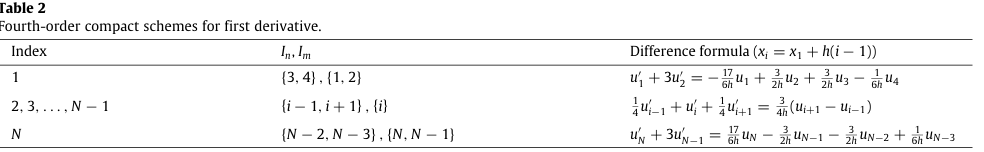

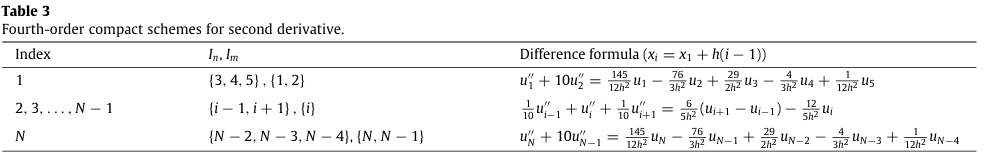

Rearrage to matrix form, we get
$$
F\frac{\partial V}{\partial S}=GV, U\frac{\partial^2 V}{\partial S^2}=WV
$$
Denote $D=F^{-1}G$ and $D^2=U^{-1}W$, the Black-Scholes PDE will look like
$$
\frac{\partial V}{\partial t}=LV
$$
where $L = \frac{1}{2} \sigma^2 S^2 D^2 + rSD - rI$, $I$ is an identity matrix.

**Time Discretization**

(1) Crank-Nicolson method

The weakness of the explicit and implicit method is that the order of the global truncation error in time is $O(\delta)$, which requires that the time step is much smaller than the spatial step size. An effective solution is to average the forward difference method and the backward difference method. It makes the global truncation error order in time $O(\delta^2)$.

(2) Fourth-order backward differentiation (BDF4)

For a general linear system, $\frac{\partial V}{\partial t}=AV+b$, the form of BDF4 is,
$$
\left( \frac{25}{12} I - \delta A \right) V^{j+1} = 4V^{j} - 3V^{j-1} + \frac{4}{3} V^{j-2} - \frac{1}{4} V^{j-3} + \delta b^{j+1}
$$

BDF4 requires the first 4 initial values. A simple way is to use the Crank-Nicolson method twice to obtain $V^1$  and $V^2$ from $V^0$ and then use the BDF3 to obtain the value of $V^3$, and finally the value of $V^4$ is obtained by BDF4.

The form of BDF3 is,
$$
\left( \frac{11}{6} I - \delta A \right) V^{j+1} = 3V^{j} - \frac{3}{2} V^{j-1} + \frac{1}{3} V^{j-2} + \delta b^{j+1}
$$

# Black-Scholes Finite Difference Solver

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from time import time
from matplotlib import cm
from scipy.stats import norm
from scipy.linalg import lu_factor, lu_solve
from scipy.sparse import diags, identity, csc_matrix
from scipy.sparse.linalg import splu
from scipy.interpolate import make_interp_spline

class Finite_Diff_Black_scholes():
  def __init__(self, S0, K, T, sigma, r, N, M, flag, xi=0, Smax=-1):
    '''Option setting'''
    self.S0 = S0  # Spot price of underlying asset
    self.K = K  # Strike price
    self.T = T  # Maturity
    self.sigma = sigma  # Volatility of underlying asset
    self.r = r  # Risk-free rate
    '''General grid setting'''
    self.M = M  # State steps
    self.N = N  # Time steps
    self.flag = flag.lower()  # Indicator for "call" or "put" option
    self.dt = self.T / self.N  # Time step size
    self.iValues = np.arange(1, self.M)
    self.jValues = np.arange(1, self.N + 1)
    '''State setting'''
    self.S_min= 0  # Min state for grid
    self.S_max = max(max(S0, K) * np.exp((r - 0.5 * sigma**2) * T + 4.0 * sigma * np.sqrt(T)), 3 * K, 3 * self.S0) if Smax == -1 else Smax # Max state for grid
    self.dS = (self.S_max - self.S_min) / self.M  # State step size
    self.SValues = np.linspace(self.S_min, self.S_max, self.M + 1)
    if xi != 0:
      self.xi = xi
      self.c1 = np.arcsinh(self.xi * (self.S_min - self.K))
      self.c2 = np.arcsinh(self.xi * (self.S_max - self.K))
      self.yValues = np.linspace(0, 1, self.M + 1)
    self.align_K(xi)
    self.alpha = 0.5 * sigma**2 * self.SValues[1:-1]**2 if xi == 0 else 0.5 * sigma ** 2 * self.phi(self.yValues[1:-1]) ** 2 / self.J(self.yValues[1:-1]) ** 2 # coef of gamma term
    self.beta = r * self.SValues[1:-1] if xi == 0 else r * self.phi(self.yValues[1:-1]) / self.J(self.yValues[1:-1]) - 0.5 * sigma**2 * self.phi(self.yValues[1:-1]) ** 2 / self.J(self.yValues[1:-1]) ** 3 * self.H(self.yValues[1:-1])# coef of delta term
    '''Result setting'''
    self.V = np.zeros(shape=(self.M + 1, self.N + 1))  # grid of option value
    self.set_conditions()  # Initial and boundary conditions
    self.price = 0  # Numerical price
    self.bs_price = self.black_scholes()  # Analytical price

  def align_K(self, xi):
    """
    Make sure the strike price is aligned with the grid.
    """
    if xi == 0:
      ratio = (self.K - self.S_min) / (self.S_max - self.S_min)
      m = int(np.round(self.M * ratio))
      self.dS = (self.K - self.S_min) / m
      self.S_max = self.S_min + self.M * self.dS
      self.SValues = np.linspace(self.S_min, self.S_max, self.M + 1)
    else:
      y_K = -self.c1 / (self.c2 - self.c1)
      m = int(np.round(y_K * self.M))
      self.dS = 1.0 / self.M
      # y_K = m * self.dS
      self.c2 = self.c1 * (1.0 - self.M / m)
      self.S_max = self.phi(1)
      self.SValues = self.phi(self.yValues)
    self.SValues[0] = self.S_min
    self.SValues[m] = self.K
    self.SValues[-1] = self.S_max

  def phi(self, y):
    # S = phi(y)
    return np.sinh(self.c2 * y + self.c1 * (1.0 - y)) / self.xi + self.K

  def J(self, y):
    # J(y) = dS/ dy
    return np.cosh(self.c2 * y + self.c1 * (1.0 - y))  / self.xi * (self.c2 - self.c1)

  def H(self, y):
    # H(y) = d2S / dy2
    return  np.sinh(self.c2 * y + self.c1 * (1.0 - y)) / self.xi * (self.c2 - self.c1)**2

  def set_conditions(self):
    if self.flag == "call":
      # Initial condition
      self.V[:, 0] = np.maximum(self.SValues - self.K, 0)
      # Boundary condition
      self.V[0, 1:] = 0
      self.V[-1, 1:] = self.S_max - self.K * np.exp(-self.r * self.jValues * self.dt)
    elif self.flag == "put":
      # Initial condition
      self.V[:, 0] = np.maximum(self.K - self.SValues, 0)
      # Boundary conditions
      self.V[0, 1:] = self.K * np.exp(-self.r * self.jValues * self.dt)
      self.V[-1, 1:] = 0
    else:
      raise ValueError("Invalid flag. Must be either 'call' or 'put'.")

  def black_scholes(self):
    """
    Analytical solution of Black-Scholes PDE for European option.
    """
    d1 = (np.log(self.S0 / self.K) + (self.r + 0.5 * self.sigma**2) * self.T) / (self.sigma * np.sqrt(self.T))
    d2 = d1 - self.sigma * np.sqrt(self.T)

    if self.flag == 'call':
      return self.S0 * norm.cdf(d1) - self.K * np.exp(-self.r * self.T) * norm.cdf(d2)
    elif self.flag == 'put':
      return self.K * np.exp(-self.r * self.T) * norm.cdf(-d2) - self.S0 * norm.cdf(-d1)

  def generate_CN(self):
    """
    The formula for Crank-Nicolson method is given by M2 * V(j) + v2 = M1 * V(j-1) + v1, this function generates M1, M2, and a[1], c[N-2] for v1 and v2.
    """
    size = self.M - 1
    a = self.dt * (0.5 * self.alpha / self.dS**2 - 0.25 * self.beta / self.dS)
    b  = self.dt * (0.5 * self.r + self.alpha / self.dS**2)
    c = self.dt * (0.5 * self.alpha / self.dS**2 + 0.25 * self.beta / self.dS)

    M1 = diags([a[1:], 1 - b, c[:-1]], [-1, 0, 1], shape=(size, size), format='csc')
    M2 = diags([-a[1:], 1 + b, -c[:-1]], [-1, 0, 1], shape=(size, size), format='csc')

    return M1, M2, a[0], c[-1]

  def generate_v(self, a, c, j):
    """
    The formula for Crank-Nicolson method is given by M2 * V(j) + v2 = M1 * V(j-1) + v1, this function generates v = v1 - v2.
    """
    v = np.zeros(self.M - 1)
    v[0] = a * (self.V[0, j-1] + self.V[0, j])
    v[-1] = c * (self.V[-1, j-1] + self.V[-1, j])

    return v

  def Euro_Crank_Nicolson(self):
    M1, M2, a, c = self.generate_CN()

    lu = splu(M2)
    for j in range(1, self.N + 1):
      v = self.generate_v(a, c, j)
      self.V[1:-1, j] = lu.solve(M1.dot(self.V[1:-1, j-1]) + v)

    self.price = np.interp(self.S0, self.SValues, self.V[:, -1])

  def generate_A(self):
    """
    Write the first derivative in the form of ∂V/∂S=AV+b1, this function generates A.
    """
    size = self.M - 1
    A = diags([1, -8, 0, 8, -1], [-2, -1, 0, 1, 2], shape=(size, size), format='lil')
    A[0, :4] = [-10, 18, -6, 1]
    A[-1, -4:] = [-1, 6, -18, 10]
    return A.tocsc() / (12 * self.dS)

  def generate_b1(self, j):
    """
    Write the first derivative in the form of ∂V/∂S=AV+b1, this function generates b1.
    """
    v0 = self.V[0, j]
    vN = self.V[-1, j]
    b1 = np.zeros(self.M - 1)
    b1[[0, 1, -2, -1]] = [-3 * v0, 1 * v0, -1 * vN, 3 * vN]
    return b1 / (12 * self.dS)

  def generate_B(self):
    """
    Write the second derivative in the form of ∂2V/∂S2= BV+b2, this function generates B.
    """
    size = self.M - 1
    B = diags([-1, 16, -30, 16, -1], [-2, -1, 0, 1, 2], shape=(size, size), format='lil')
    B[0, :5] = [-15, -4, 14, -6, 1]
    B[-1, -5:] = [1, -6, 14, -4, -15]
    return B.tocsc() / (12 * self.dS**2)

  def generate_b2(self, j):
    """
    Write the second derivative in the form of ∂2V/∂S2= BV+b2, this function generates b1.
    """
    v0 = self.V[0, j]
    vN = self.V[-1, j]
    b2 = np.zeros(self.M - 1)
    b2[[0, 1, -2, -1]] = [10 * v0, -1 * v0, -1 * vN, 10 * vN]
    return b2 / (12 * self.dS**2)

  def generate_P(self):
    """
    Write the Black-Scholes PDE in the form of ∂V/∂t= PV+Q, this function generates P.
    """
    A = self.generate_A()
    B = self.generate_B()
    P = B.multiply(self.alpha[:, None]) + A.multiply(self.beta[:, None]) - self.r * identity(self.M - 1, format="csc")
    return P

  def generate_Q(self, j):
    """
    Write the Black-Scholes PDE in the form of ∂V/∂t= PV+Q, this function generates P.
    """
    b1 = self.generate_b1(j)
    b2 = self.generate_b2(j)
    Q = self.alpha * b2 + self.beta * b1
    return Q

  def Euro_BDF4(self):
    # Use the Crank–Nicolson method twice to obtain the values of V(1) and V(2) from V(0)
    M1, M2, a, c = self.generate_CN()
    lu_cn = splu(M2)
    self.V[1:-1, 1] = lu_cn.solve(M1.dot(self.V[1:-1, 0]) + self.generate_v(a, c, 1))
    self.V[1:-1, 2] = lu_cn.solve(M1.dot(self.V[1:-1, 1]) + self.generate_v(a, c, 2))

    # Use BDF3 method to obtain the value of V(3)
    P = self.generate_P()
    Q = self.generate_Q(3)
    I = identity(self.M - 1, format="csc")

    rhs = 3 * self.V[1:-1, 2] - 1.5 * self.V[1:-1, 1] + self.V[1:-1, 0] / 3 + self.dt * Q
    lhs = 11 / 6 * I - self.dt * P
    self.V[1:-1, 3] = splu(lhs).solve(rhs)

    # BDF4
    lhs = 25 / 12 * I - self.dt * P
    lu_bdf = splu(lhs)
    for j in range(4, self.N + 1):
      Q = self.generate_Q(j)
      rhs = 4 * self.V[1:-1, j-1] - 3 * self.V[1:-1, j-2] + 4 * self.V[1:-1, j-3] / 3 - self.V[1:-1, j-4] / 4 + self.dt * Q
      self.V[1:-1, j] = lu_bdf.solve(rhs)


    self.price = make_interp_spline(self.SValues, self.V[:, -1], k=4)(self.S0)

  def generate_F(self):
    """
    Write the first derivative in the form of ∂V/∂S=(F^-1*G)V, this function generates F.
    """
    size = self.M - 1
    F = diags([0.25, 1, 0.25], [-1, 0, 1], shape=(size, size), format='lil')
    F[0, 1] = 3
    F[-1, -2] = 3
    return F.tocsc()

  def generate_G(self):
    """
    Write the first derivative in the form of ∂V/∂S=(F^-1*G)V, this function generates G.
    """
    size = self.M - 1
    G = diags([-3/4, 0, 3/4], [-1, 0, 1], shape=(size, size), format='lil')
    G[0, :4] = [-17/6, 3/2, 3/2, -1/6]
    G[-1, -4:] = [1/6, -3/2, -3/2, 17/6]
    return G.toarray() / self.dS

  def generate_U(self):
    """
    Write the second derivative in the form of ∂2V/∂S2=(U^-1*W)V, this function generates U.
    """
    size = self.M - 1
    U = diags([0.1, 1, 0.1], [-1, 0, 1], shape=(size, size), format='lil')
    U[0, 1] = 10
    U[-1, -2] = 10
    return U.tocsc()

  def generate_W(self):
    """
    Write the second derivative in the form of ∂2V/∂S2=(U^-1*W)V, this function generates U.
    """
    size = self.M - 1
    W = diags([6/5, -12/5, 6/5], [-1, 0, 1], shape=(size, size), format='lil')
    W[0, :5] = [145/12, -76/3, 29/2, -4/3, 1/12]
    W[-1, -5:] = [1/12, -4/3, 29/2, -76/3, 145/12]
    return W.toarray() / self.dS**2

  def generate_L(self):
    """
    Write the Black-Scholes PDE in the form of ∂V/∂t= LV, this function generates L.
    """
    F = self.generate_F()
    G = self.generate_G()
    U = self.generate_U()
    W = self.generate_W()
    L = self.alpha[:, None] * splu(U).solve(W) + self.beta[:, None] * splu(F).solve(G)
    np.fill_diagonal(L, L.diagonal() - r)
    return L

  def Euro_compact_BDF4(self):
    # Use the Crank–Nicolson method twice to obtain the values of V(1) and V(2) from V(0)
    M1, M2, a, c = self.generate_CN()
    lu_cn = splu(M2)
    self.V[1:-1, 1] = lu_cn.solve(M1.dot(self.V[1:-1, 0]) + self.generate_v(a, c, 1))
    self.V[1:-1, 2] = lu_cn.solve(M1.dot(self.V[1:-1, 1]) + self.generate_v(a, c, 2))

    # Use the BDF3 method to obtain the value of V(3)
    L = self.generate_L()

    rhs = 3 * self.V[1:-1, 2] - 1.5 * self.V[1:-1, 1] + self.V[1:-1, 0] / 3
    lhs = - self.dt * L
    np.fill_diagonal(lhs, lhs.diagonal() + 11 / 6)
    lu, piv = lu_factor(lhs)
    self.V[1:-1, 3] = lu_solve((lu, piv), rhs)

    # BDF4
    lhs = - self.dt * L
    np.fill_diagonal(lhs, lhs.diagonal() + 25 / 12)
    lu, piv = lu_factor(lhs)
    for j in range(4, self.N + 1):
      rhs = 4 * self.V[1:-1, j-1] - 3 * self.V[1:-1, j-2] + 4 * self.V[1:-1, j-3] / 3 - self.V[1:-1, j-4] / 4
      self.V[1:-1, j] = lu_solve((lu, piv), rhs)

    self.price = make_interp_spline(self.SValues, self.V[:, -1], k=4)(self.S0)


In [2]:
def plot_payoff(opt):
  T = np.linspace(0, opt.T, opt.N + 1)
  fig = plt.figure(figsize=(15,6))
  ax1 = fig.add_subplot(121)
  ax2 = fig.add_subplot(122, projection='3d')

  ax1.plot(opt.SValues, opt.V[:, 0], color='blue',label="Payoff")
  ax1.plot(opt.SValues, opt.V[:, -1], color='red',label="FD curve")
  ax1.set_xlabel("S"); ax1.set_ylabel("price")
  ax1.legend(loc='upper left')
  ax1.set_title("FD price at t=0")

  X, Y = np.meshgrid(T, opt.SValues)
  ax2.plot_surface(Y, X, opt.V, cmap=cm.ocean)
  ax2.set_title("FD price surface")
  ax2.set_xlabel("S")
  ax2.set_ylabel("t")
  ax2.set_zlabel("option")
  ax2.view_init(30, -100) # this function rotates the 3d plot
  plt.show()


# Option pricing example

In [3]:
# Parameters
S0 = 15  # spot price
K = 15  # strike price
T = 0.5  # maturity
sigma = 0.3  # volatility
r = 0.02  # risk-free rate
N = 100  # time steps
M = 100  # state steps

opt = Finite_Diff_Black_scholes(S0, K, T, sigma, r, N, M, "call")

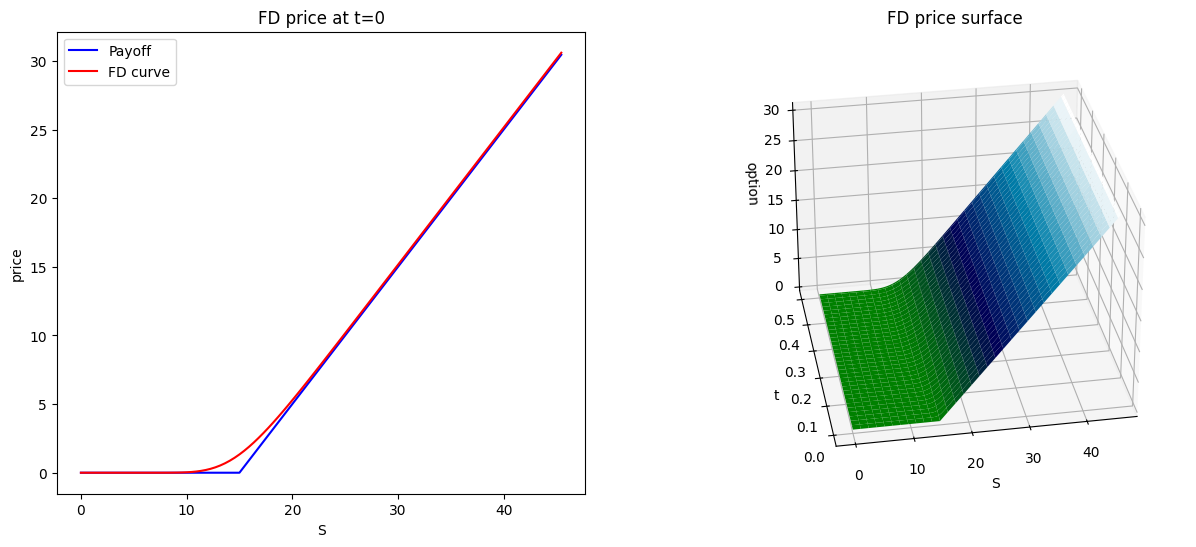

In [4]:
opt.Euro_Crank_Nicolson()
plot_payoff(opt)

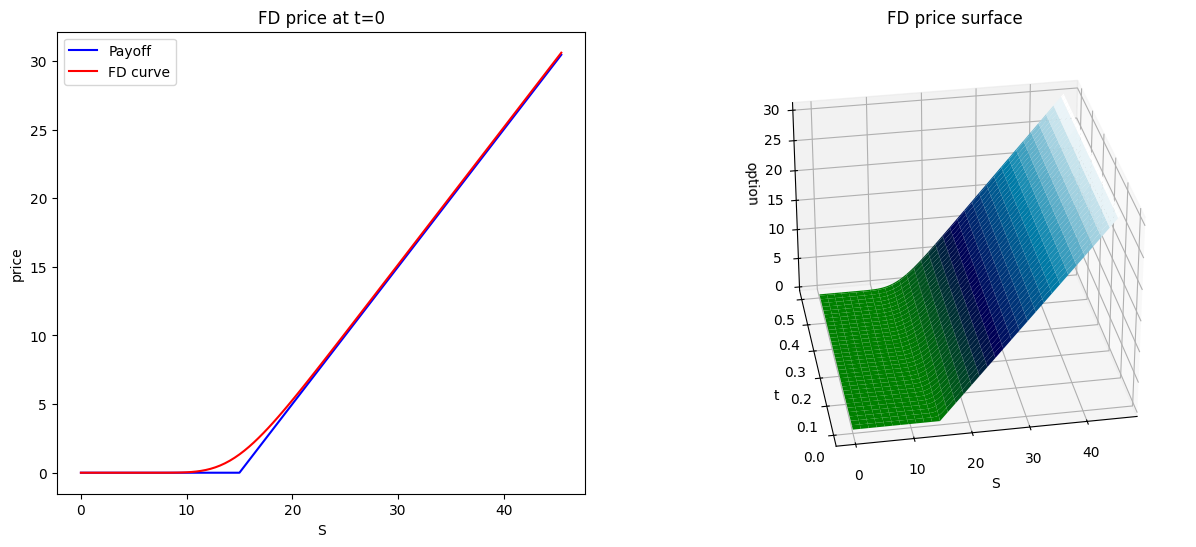

In [5]:
opt.Euro_BDF4()
plot_payoff(opt)

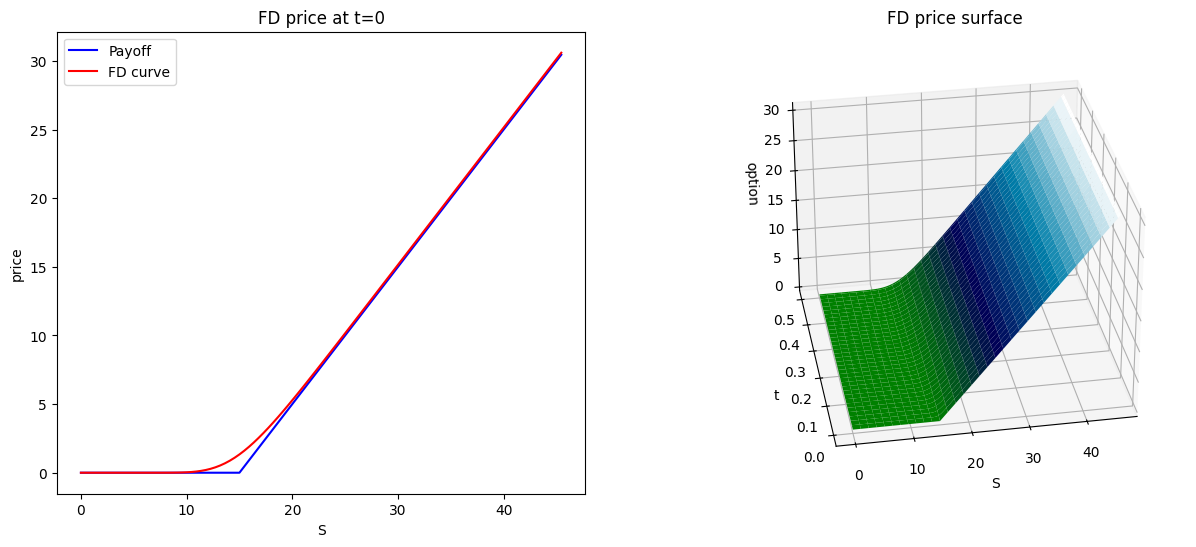

In [6]:
opt.Euro_compact_BDF4()
plot_payoff(opt)

**Observation**

All three methods can price option value correctly.

# Numerical tests

In [7]:
def exact_bs(opt):
    S = opt.SValues
    T = opt.T
    K = opt.K
    r = opt.r
    sigma = opt.sigma
    flag = opt.flag

    d1 = np.zeros_like(S)
    d2 = np.zeros_like(S)
    mask = S > 0
    d1[mask] = (np.log(S[mask] / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2[mask] = d1[mask] - sigma * np.sqrt(T)

    exact = np.zeros_like(S)
    if flag == 'call':
        exact[mask] = S[mask] * norm.cdf(d1[mask]) - K * np.exp(-r * T) * norm.cdf(d2[mask])
        exact[~mask] = 0.0
    elif flag == 'put':
        exact[mask] = K * np.exp(-r * T) * norm.cdf(-d2[mask]) - S[mask] * norm.cdf(-d1[mask])
        exact[~mask] = K * np.exp(-r * T)
    return exact

In [8]:
def compute_error(opt, norm_type='max'):
    exact = exact_bs(opt)
    numerical = opt.V[:, -1]

    if norm_type == 'max':
        return np.max(np.abs(numerical - exact))
    elif norm_type == 'l2':
        return np.sqrt(opt.dS * np.sum((numerical - exact)**2))

In [9]:
def error_and_order(S0, K, T, sigma, r, flag, xi=0, Smax=-1, norm_type='max', test_n=100):
    # computation time
    time_cn = np.zeros(4)
    time_bdf4 = np.zeros(4)
    time_com_bdf4 = np.zeros(4)
    # truncation error
    error_cn = np.zeros(4)
    error_bdf4 = np.zeros(4)
    error_com_bdf4 = np.zeros(4)

    grids = [10, 20, 40, 80]
    for i in range(len(grids)):
        N = grids[i]  # time steps
        M = grids[i]  # state steps
        if xi == 0 and Smax != -1:
          Smax = -1
        opt = Finite_Diff_Black_scholes(S0, K, T, sigma, r, N, M, flag, xi, Smax)

        start = time()
        for _ in range(test_n):
            opt.Euro_Crank_Nicolson()
        end = time()
        time_cn[i] = (end - start) / test_n
        error_cn[i] = compute_error(opt)

        start = time()
        for _ in range(test_n):
            opt.Euro_BDF4()
        end = time()
        time_bdf4[i] = (end - start) / test_n
        error_bdf4[i] = compute_error(opt)

        start = time()
        for _ in range(test_n):
            opt.Euro_compact_BDF4()
        end = time()
        time_com_bdf4[i] = (end - start) / test_n
        error_com_bdf4[i] = compute_error(opt)

    results_dict = {
        'Crank-Nicolson': {'error': error_cn, 'time': time_cn},
        'BDF4': {'error': error_bdf4, 'time': time_bdf4},
        'Compact BDF4': {'error': error_com_bdf4, 'time': time_com_bdf4},
    }

    rows = []
    for scheme_name, data in results_dict.items():
      errors = np.asarray(data['error'])
      times = np.asarray(data['time'])

      orders = ['-']
      for i in range(1, len(grids)):
        orders.append(f'{np.log(errors[i - 1] / errors[i]) / np.log(grids[i] / grids[i - 1]):.4f}')

      for idx, g in enumerate(grids):
        rows.append({
            'Scheme': scheme_name if idx == 0 else '',
            'Grid': f'{g} × {g}',
            'Error': f'{errors[idx]:.4e}' if errors[idx] < 1e-3 else f'{errors[idx]:.4f}',
            'Order': orders[idx],
            'Computing time': f'{times[idx]:.4f} s',
        })

    df = pd.DataFrame(rows)
    return df


In [10]:
error_and_order(S0, K, T, sigma, r, 'put', xi=0, norm_type='max', test_n=1000)

,Scheme,Grid,Error,Order,Computing time
0,Crank-Nicolson,10 × 10,0.4218,-,0.0029 s
1,,20 × 20,0.0791,2.4147,0.0009 s
2,,40 × 40,0.0209,1.9175,0.0017 s
3,,80 × 80,0.0048,2.1380,0.0030 s
4,BDF4,10 × 10,0.3544,-,0.0100 s
5,,20 × 20,0.0558,2.6679,0.0041 s
6,,40 × 40,0.0146,1.9383,0.0053 s
7,,80 × 80,0.0033,2.1604,0.0069 s
8,Compact BDF4,10 × 10,0.3424,-,0.0069 s
9,,20 × 20,0.0534,2.6820,0.0046 s


**Observation**

Crank-Nicolson method is the fastest, but it also has the largest truncation error. However, in option pricing, the estimate should be accurate up to cent, which means that Crank-Nicolson is enough to handle it with a 80 by 80 grid.

**Constraint**

Though we apply fourth-order methods both in space and time, the results don't show fourth-order accuracy because of non-smoothness, i.e. the payoff function is non-differentiable at the strike price K.

**Improvement**

Apply the grid refinement method to distribute more points in the
vicinity of the bad point (strike price), so that the value of the derivative around the non-differentiable point can be approximated by a smaller step size.

# Coordinate transformation

Use coordinate transformation as follows:

$$
y = \psi(S) = \frac{\sinh^{-1}(\xi(S - X)) - c_1}{c_2 - c_1},
$$

where $c_1 = \sinh^{-1}(\xi(S_{\min} - X))$, $c_2 = \sinh^{-1}(\xi(S_{\max} - X))$ are both constants and parameter $\xi$ is called stretching factor. It is not difficult to verify that this transformation maps $S \in [S_{\min}, S_{\max}]$ on original coordinate system into $y \in [0, 1]$ on new coordinate system. The inverse transformation is

$$
S = \psi^{-1}(y) = \varphi(y) = \frac{1}{\xi}\sinh(c_2 y + c_1(1 - y)) + X.
$$

After the coordinate transformation, the coefficients also change and can be obtained by the chain rule
$$
\frac{\partial V}{\partial S} = \frac{\partial V}{\partial y}\frac{dy}{dS} = \frac{\partial V}{\partial y}\left(\frac{dS}{dy}\right)^{-1} = \frac{1}{\varphi'(y)}\frac{\partial V}{\partial y}
$$

$$
\frac{\partial^2 V}{\partial S^2} = \left(\frac{dS}{dy}\right)^{-1}\frac{\partial}{\partial y}\left(\left(\frac{dS}{dy}\right)^{-1}\frac{\partial V}{\partial y}\right) = \frac{1}{(\varphi'(y))^2}\frac{\partial^2 V}{\partial y^2} - \frac{\varphi''(y)}{(\varphi'(y))^3}\frac{\partial V}{\partial y}.
$$

Thus the transformed Black-Scholes PDE is

$$
\frac{\partial V}{\partial t} = \frac{1}{2}\sigma^2 \frac{\varphi(y)^2}{J(y)^2}\frac{\partial^2 V}{\partial y^2} + \left(r\frac{\varphi(y)}{J(y)} - \frac{1}{2}\sigma^2 \frac{\varphi(y)^2}{J(y)^3}H(y)\right)\frac{\partial V}{\partial y} - rV,
$$
where $J(y) = \varphi'(y)$ and $H(y) = \varphi''(y)$.

Text(0.5, 1.0, 'Coordinate transformation($\\xi=10$)')

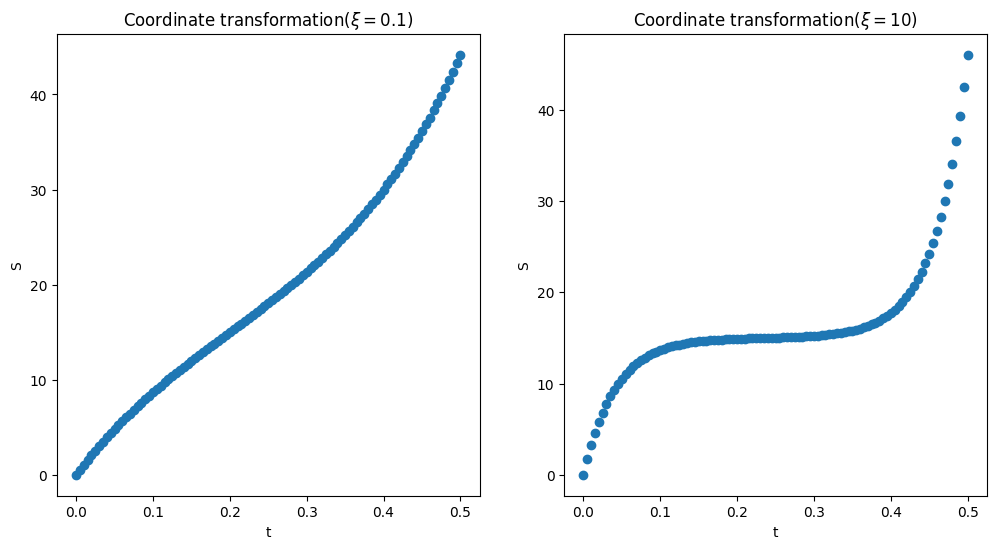

In [11]:
opt = Finite_Diff_Black_scholes(S0, K, T, sigma, r, N, M, "call", xi=0.1)
plt.figure(figsize=(12,6))
plt.subplot(121)
plt.scatter(opt.dt * np.arange(0, opt.M + 1), opt.SValues)
plt.xlabel("t")
plt.ylabel("S")
plt.title(r"Coordinate transformation($\xi=0.1$)")

opt = Finite_Diff_Black_scholes(S0, K, T, sigma, r, N, M, "call", xi=10)
plt.subplot(122)
plt.scatter(opt.dt * np.arange(0, opt.M + 1), opt.SValues)
plt.xlabel("t")
plt.ylabel("S")
plt.title(r"Coordinate transformation($\xi=10$)")

**Observation**

1. This coordinate transformation concentrate grid points near the strike price and space them more sparsely toward the boundaries.
2. As stretching factor $\xi$ increases, the original grids are more like to be non-uniform and clustered around the center.


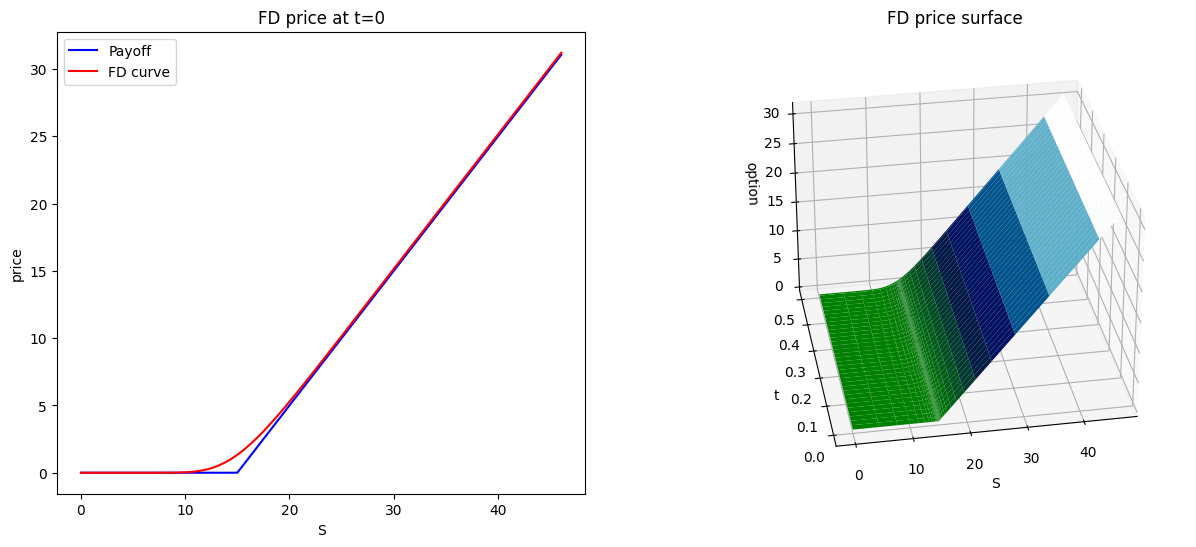

In [12]:
opt.Euro_Crank_Nicolson()
plot_payoff(opt)

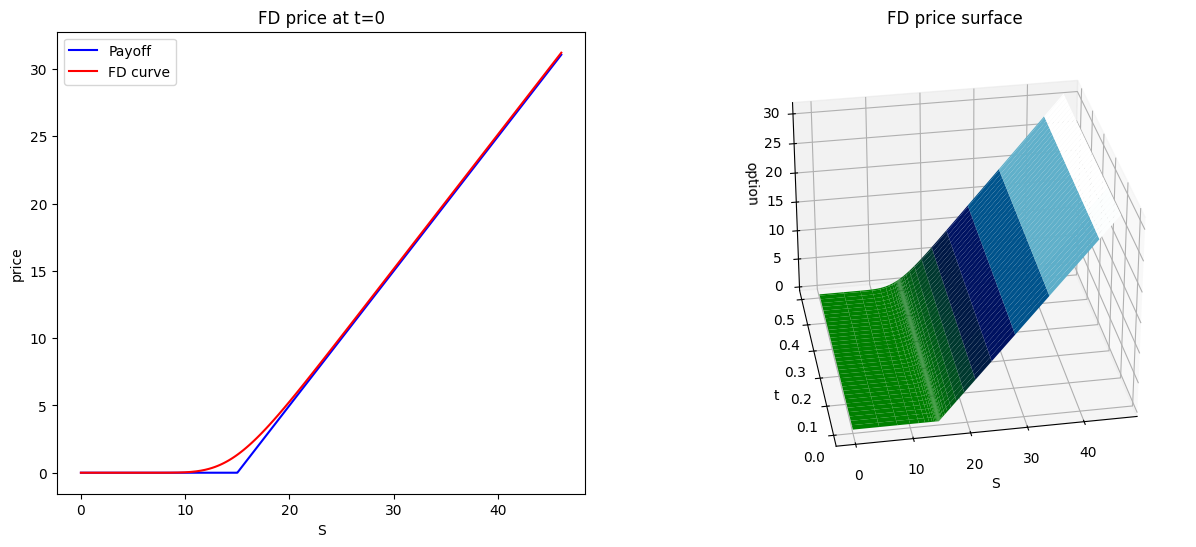

In [13]:
opt.Euro_BDF4()
plot_payoff(opt)

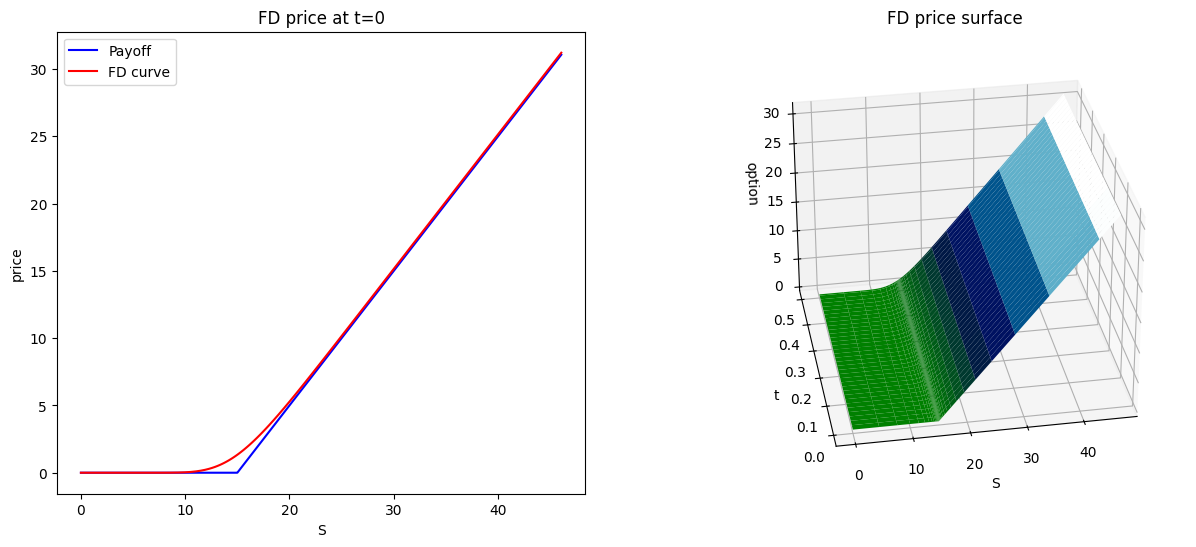

In [14]:
opt.Euro_compact_BDF4()
plot_payoff(opt)

**Observation**

All three methods under coordinate transformation can price option value correctly.

In [15]:
error_and_order(S0, K, T, sigma, r, 'put', xi=6, norm_type='max', test_n=1000)

,Scheme,Grid,Error,Order,Computing time
0,Crank-Nicolson,10 × 10,0.2027,-,0.0008 s
1,,20 × 20,0.0548,1.8871,0.0010 s
2,,40 × 40,0.0115,2.2490,0.0021 s
3,,80 × 80,0.0032,1.8615,0.0030 s
4,BDF4,10 × 10,0.0454,-,0.0037 s
5,,20 × 20,0.0032,3.8264,0.0042 s
6,,40 × 40,5.7022e-04,2.4888,0.0055 s
7,,80 × 80,6.8837e-05,3.0503,0.0075 s
8,Compact BDF4,10 × 10,0.1039,-,0.0044 s
9,,20 × 20,0.0133,2.9683,0.0038 s


In [16]:
error_and_order(S0, K, T, sigma, r, 'put', xi=12, norm_type='max', test_n=1000)

,Scheme,Grid,Error,Order,Computing time
0,Crank-Nicolson,10 × 10,0.2714,-,0.0007 s
1,,20 × 20,0.0729,1.8962,0.0015 s
2,,40 × 40,0.0157,2.2125,0.0015 s
3,,80 × 80,0.0050,1.6429,0.0022 s
4,BDF4,10 × 10,0.1227,-,0.0037 s
5,,20 × 20,0.0089,3.7862,0.0047 s
6,,40 × 40,8.1462e-04,3.4485,0.0063 s
7,,80 × 80,9.3606e-05,3.1215,0.0083 s
8,Compact BDF4,10 × 10,0.0800,-,0.0035 s
9,,20 × 20,0.0103,2.9582,0.0039 s


In [17]:
error_and_order(S0, K, T, sigma, r, 'put', xi=12, Smax=5*K, norm_type='max', test_n=1000)

,Scheme,Grid,Error,Order,Computing time
0,Crank-Nicolson,10 × 10,0.3937,-,0.0012 s
1,,20 × 20,0.0729,2.4328,0.0010 s
2,,40 × 40,0.0174,2.0667,0.0013 s
3,,80 × 80,0.0052,1.7508,0.0023 s
4,BDF4,10 × 10,0.4296,-,0.0039 s
5,,20 × 20,0.0089,5.5942,0.0054 s
6,,40 × 40,9.6510e-04,3.2040,0.0053 s
7,,80 × 80,1.0542e-04,3.1946,0.0083 s
8,Compact BDF4,10 × 10,0.2042,-,0.0033 s
9,,20 × 20,0.0103,4.3111,0.0038 s


**Observation**

The value of Smax and $\xi$ affect the numerical results. With coordinate transformation, high order methods can be accurate up to cent in a smaller grid than Crank-Nicolson method.

# Application
## Calculate Greeks

This is where high order methods excel: BDF4 and Compact BDF4 calculate more accurate Greeks than Crank-Nicolson method.

In [18]:
def get_price(S0, K, T, sigma, r, N, M, flag='put', xi=0, Smax=-1, method='compact'):
        solver = Finite_Diff_Black_scholes(S0, K, T, sigma, r, N, M, flag, xi, Smax)
        if method == 'compact':
            solver.Euro_compact_BDF4()
        elif method == 'bdf4':
            solver.Euro_BDF4()
        elif method == 'cn':
            solver.Euro_Crank_Nicolson()
        return solver.price, solver

def calculate_grid_greeks(S0, K, T, sigma, r, N, M, flag='put', xi=0, Smax=-1, method='compact'):
    price, opt = get_price(S0, K, T, sigma, r, N, M, flag, xi, Smax, method)
    V_final = opt.V[:, -1]
    V_prev = opt.V[:, -2]
    S = opt.SValues

    delta = np.gradient(V_final, S)
    gamma = np.gradient(delta, S)
    theta = (V_prev - V_final) / opt.dt

    idx = np.argmin(np.abs(V_final - price))
    greeks = {
        'Price': price,
        'Delta': delta,
        'Gamma': gamma,
        'Theta': theta,
    }
    return greeks, idx

def calculate_all_greeks_bump(S0, K, T, sigma, r, N, M, flag='put', xi=0, Smax=-1, method='compact'):
    V_base, _ = get_price(S0, K, T, sigma, r, N, M, flag, xi, Smax, method)

    h_S = 0.01 * S0
    h_vol = 0.01
    h_r = 0.01
    h_t = min(1e-4, T * 0.01)

    # Delta & Gamma
    V_S_plus, _ = get_price(S0 + h_S, K, T, sigma, r, N, M, flag, xi, Smax, method)
    V_S_minus, _ = get_price(S0 - h_S, K, T, sigma, r, N, M, flag, xi, Smax, method)
    delta = (V_S_plus - V_S_minus) / (2 * h_S)
    gamma = (V_S_plus - 2 * V_base + V_S_minus) / (h_S ** 2)

    # Theta
    V_t_minus, _ = get_price(S0, K, T - h_t, sigma, r, N, M, flag, xi, Smax, method)
    theta = -(V_base - V_t_minus) / h_t

    # Vega
    V_vol_plus, _ = get_price(S0, K, T, sigma + h_vol, r, N, M, flag, xi, Smax, method)
    V_vol_minus, _ = get_price(S0, K, T, sigma - h_vol, r, N, M, flag, xi, Smax, method)
    vega = (V_vol_plus - V_vol_minus) / (2 * h_vol)

    # Rho
    V_r_plus, _ = get_price(S0, K, T, sigma, r + h_r, N, M, flag, xi, Smax, method)
    V_r_minus, _ = get_price(S0, K, T, sigma, r - h_r, N, M, flag, xi, Smax, method)
    rho = (V_r_plus - V_r_minus) / (2 * h_r)

    greeks = {
        'Price': V_base,
        'Delta': delta,
        'Gamma': gamma,
        'Theta': theta,
        'Vega': vega,
        'Rho': rho
    }
    return greeks

def bs_greeks_analytical(S0, K, T, sigma, r, flag='put'):
    d1 = (np.log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    gamma = norm.pdf(d1) / (S0 * sigma * np.sqrt(T))
    vega = S0 * norm.pdf(d1) * np.sqrt(T)

    if flag.lower() == 'call':
        delta = norm.cdf(d1)
        theta = - (S0 * norm.pdf(d1) * sigma) / (2 * np.sqrt(T)) - r * K * np.exp(-r * T) * norm.cdf(d2)
        rho = K * T * np.exp(-r * T) * norm.cdf(d2)
    else:
        delta = norm.cdf(d1) - 1.0
        theta = - (S0 * norm.pdf(d1) * sigma) / (2 * np.sqrt(T)) + r * K * np.exp(-r * T) * norm.cdf(-d2)
        rho = - K * T * np.exp(-r * T) * norm.cdf(-d2)

    return {
        'Delta': delta,
        'Gamma': gamma,
        'Theta': theta,
        'Vega': vega,
        'Rho': rho
    }

In [19]:
fd_greeks_cn = calculate_all_greeks_bump(S0, K, T, sigma, r, 80, 80, flag='put', xi=0, method='cn')
fd_greeks_bdf = calculate_all_greeks_bump(S0, K, T, sigma, r, 80, 80, flag='put', xi=12, Smax=5*K, method='bdf4')
fd_greeks_compact = calculate_all_greeks_bump(S0, K, T, sigma, r, 80, 80, flag='put', xi=12, Smax=5*K, method='compact')

grid_greeks_cn, idx_cn = calculate_grid_greeks(S0, K, T, sigma, r, 80, 80, flag='put', xi=0, method='cn')
grid_greeks_bdf, idx_bdf = calculate_grid_greeks(S0, K, T, sigma, r, 80, 80, flag='put', xi=12, Smax=5*K, method='bdf4')
grid_greeks_compact, idx_compact = calculate_grid_greeks(S0, K, T, sigma, r, 80, 80, flag='put', xi=12, Smax=5*K, method='compact')

exact_greeks = bs_greeks_analytical(S0, K, T, sigma, r, flag='put')

In [20]:
for grid_greeks, idx, method in zip([grid_greeks_cn, grid_greeks_bdf, grid_greeks_compact], [idx_cn, idx_bdf, idx_compact],['Crank-Nicolson', 'BDF4', 'Compact BDF4']):
    print(f"\n{method}:")
    print(f"{'Greek':<8} {'FD Value':<12} {'Analytical':<12} {'Error':<12}")
    print("-" * 45)
    for key in ['Delta', 'Gamma', 'Theta']:
        err = np.abs((grid_greeks[key] - exact_greeks[key]))
        print(f"{key:<8} {grid_greeks[key][idx]:<12.6f} {exact_greeks[key]:<12.6f} {err[idx]:<12.6e}")


Crank-Nicolson:
Greek    FD Value     Analytical   Error       
---------------------------------------------
Delta    -0.439674    -0.439118    5.557919e-04
Gamma    0.123652     0.123913     2.607451e-04
Theta    -1.108229    -1.099130    9.098842e-03

BDF4:
Greek    FD Value     Analytical   Error       
---------------------------------------------
Delta    -0.439128    -0.439118    1.067707e-05
Gamma    0.123942     0.123913     2.966204e-05
Theta    -1.103333    -1.099130    4.203551e-03

Compact BDF4:
Greek    FD Value     Analytical   Error       
---------------------------------------------
Delta    -0.439107    -0.439118    1.103974e-05
Gamma    0.123926     0.123913     1.305129e-05
Theta    -1.103266    -1.099130    4.136128e-03


In [21]:
for fd_greeks, method in zip([fd_greeks_cn, fd_greeks_bdf, fd_greeks_compact], ['Crank-Nicolson', 'BDF4', 'Compact BDF4']):
    print(f"\n{method}:")
    print(f"{'Greek':<8} {'FD Value':<12} {'Analytical':<12} {'Error':<12}")
    print("-" * 45)
    for key in ['Delta', 'Gamma', 'Theta', 'Vega', 'Rho']:
        err = abs(fd_greeks[key] - exact_greeks[key])
        print(f"{key:<8} {fd_greeks[key]:<12.6f} {exact_greeks[key]:<12.6f} {err:<12.6e}")


Crank-Nicolson:
Greek    FD Value     Analytical   Error       
---------------------------------------------
Delta    -0.440278    -0.439118    1.159995e-03
Gamma    0.452731     0.123913     3.288182e-01
Theta    -1.104222    -1.099130    5.092334e-03
Vega     4.198729     4.182052     1.667768e-02
Rho      -3.886620    -3.887141    5.213062e-04

BDF4:
Greek    FD Value     Analytical   Error       
---------------------------------------------
Delta    -0.439179    -0.439118    6.143083e-05
Gamma    0.123917     0.123913     4.239589e-06
Theta    -1.099116    -1.099130    1.374025e-05
Vega     4.181809     4.182052     2.428828e-04
Rho      -3.887492    -3.887141    3.516037e-04

Compact BDF4:
Greek    FD Value     Analytical   Error       
---------------------------------------------
Delta    -0.439159    -0.439118    4.173581e-05
Gamma    0.123908     0.123913     4.923993e-06
Theta    -1.099051    -1.099130    7.894915e-05
Vega     4.181596     4.182052     4.555400e-04
Rho    

**References**

[1] Hu, Jinhao, and Siqing Gan. "High order method for Black–Scholes PDE." Computers & Mathematics with Applications 75.7 (2018): 2259-2270.

[2] Tangman, D. Y., A. Gopaul, and M. Bhuruth. "Numerical pricing of options using high-order compact finite difference schemes." Journal of Computational and Applied Mathematics 218.2 (2008): 270-280.